# 1. Importación

Carga de las librerías, del modelo final guardado por `04_model_training.ipynb` (`models/valencia/price_model.pkl`, `models/valencia/model_metadata.json`) y del test (`data/processed/valencia/listings_test.csv`). Este notebook no reentrena nada, parte de lo que ya quedó guardado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load("/Users/yagocoll/Documents/Master/Airbnb/models/valencia/price_model.pkl")

with open("/Users/yagocoll/Documents/Master/Airbnb/models/valencia/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/valencia/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 110.42846365835543,
 'MAE': 39.64633545127884,
 'R2': 0.37294957844113097,
 'MAPE': 24.096367659813854,
 'R2_log': 0.7612521665221308}

## 2. Reconstruir predicciones

Mismos `feature_cols`/`target` que en el entrenamiento (guardados en `metadata`), para tener `y_test` y las predicciones disponibles para todo el análisis que sigue.

### 2.1 X e y de test

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(1447, 81)

### 2.2 Función `evaluate`

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

El modelo predice en escala `log1p(price)`; se deshace con `expm1` antes de evaluar nada.

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(110.42846365835543),
 'MAE': 39.64633545127884,
 'R2': 0.37294957844113097,
 'MAPE': np.float64(24.096367659813854)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=110.43€, MAE=39.65€, R²=0.37, MAPE=24.10%): el modelo cargado predice igual que cuando se guardó, así que el análisis de errores parte de una base fiable.

A diferencia de Barcelona (donde las 5 features nuevas de amenities/densidad apenas cambiaban el MAE), en la importancia de variables de `04_model_training.ipynb` dos de ellas (`has_ac`, `n_amenities`) sí entraron en el top 15, con un peso modesto pero no despreciable — coherente con el hallazgo de la EDA de que `has_pool`/`has_ac` se relacionan más con el precio en Valencia que en Barcelona.

## 3. Predicción vs. realidad

Scatter de precio predicho contra precio real, y distribución de los residuos (`predicho - real`). El objetivo es detectar sesgos sistemáticos que un único R² no muestra.

### 3.1 Predicho vs. real

(0.0, 1500.0)

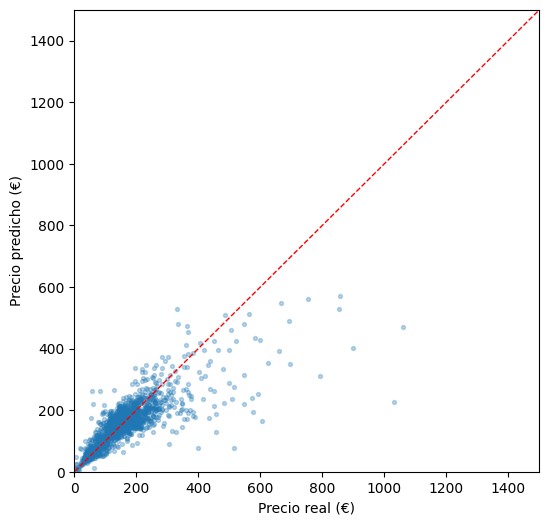

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 1500]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Para precios bajos y medios los puntos siguen razonablemente la diagonal. A partir de unos 300-400€, cada vez más puntos caen por debajo: **el modelo tiende a subestimar los anuncios más caros**, el mismo patrón que en Barcelona.

### 3.2 Distribución de los residuos

Media: -10.372714919670637
Mediana: 1.7772303255159159


(-500.0, 500.0)

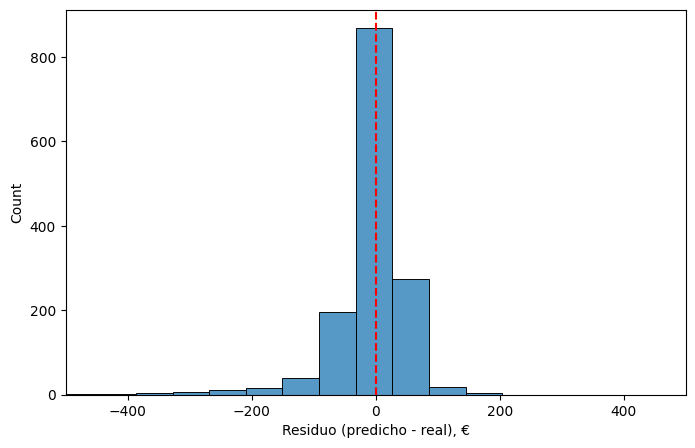

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)

La mediana del residuo es prácticamente 0 (+1.78€), pero la **media es -10.37€**, bastante más negativa — la misma lección que en Barcelona: hay una cola de subestimaciones grandes en una sola dirección que arrastra la media, aunque la mitad de los anuncios se acierten casi exactos.

### 3.3 ¿El sesgo depende del precio?

(0.0, 1500.0)

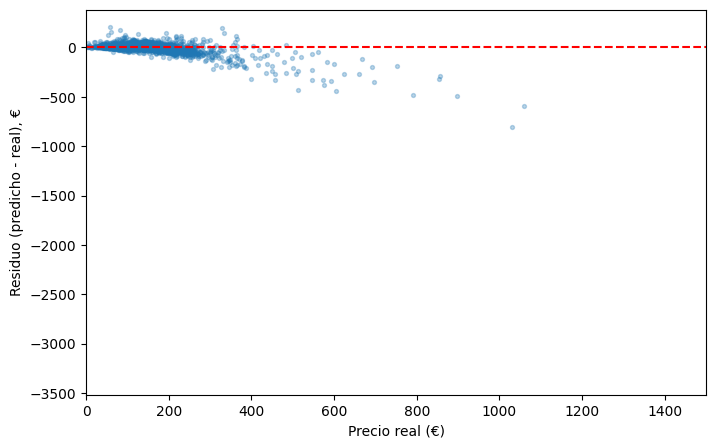

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 1500)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(3.459, 86.044]",12.039888,6.119400,290
"(86.044, 135.722]",19.023585,19.045876,289
"(135.722, 166.602]",10.114482,9.354582,289
"(166.602, 216.064]",-9.490306,-13.279251,289
"(216.064, 3511.0]",-83.376168,-50.899669,290


Confirmado con números, y con un matiz que no aparecía en Barcelona: en los tres quintiles más bajos el residuo medio es **positivo** (+12.0€, +19.0€, +10.1€, el modelo sobreestima ligeramente los anuncios baratos), el cuarto quintil ya es negativo (-9.5€), y en el quintil más caro (por encima de 216€) el residuo medio es **-83.4€** (mediana -50.9€) — una subestimación severa, del mismo orden que la de Barcelona (-87.9€) pese a que el precio medio de Valencia es bastante más bajo.

Misma explicación que en Barcelona: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta se traduce en un error absoluto grande al deshacer el logaritmo. El sesgo hacia sobreestimar lo barato y subestimar lo caro es una limitación real del modelo, no una anécdota.

## 4. Errores por segmento

MAE/RMSE desglosados por `room_type`, por distrito y por rango de precio.

### 4.1 Por `room_type`

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,121.73,44.22,0.29,22.02,1145
Private room,47.78,22.42,0.45,32.00,297
Shared room,13.75,12.09,0.78,29.63,4
Hotel room,28.31,28.31,NaN,33.71,1


`Entire home/apt` (1145 filas, la mayoría del test) tiene el RMSE/MAE más altos en euros (121.73€/44.22€), esperable por ser la categoría con precios más altos y dispersos. `Private room` tiene errores mucho más bajos (MAE=22.42€, R²=0.45, incluso mejor que el de `Entire home/apt`). `Shared room` (4 filas) y `Hotel room` (1 fila) tienen muestra demasiado pequeña para sacar ninguna conclusión — con una sola fila ni siquiera se puede calcular un R².

### 4.2 Por distrito

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Poblats Maritims,79.70,43.55,0.53,29.39,283
Ciutat Vella,70.01,42.92,0.57,25.14,236
Quatre Carreres,78.33,40.14,0.62,22.33,149
Camins al Grau,284.51,60.68,0.09,25.56,146
L'Eixample,86.81,46.59,0.63,20.26,116
Extramurs,47.47,30.28,0.56,21.99,114
Algiros,40.41,23.32,0.84,23.06,70
La Saidia,56.02,32.19,0.50,21.03,56
Jesus,31.81,23.18,0.72,19.00,51


`Camins al Grau` destaca muy negativamente: RMSE=284.51€ y R²=0.09, muy por detrás de cualquier otro distrito pese a tener una muestra normal (146 filas). No es un problema general del distrito: se explica por completo en la sección 5, donde 3 de los 15 peores errores de todo el test (incluido el peor de todos, -3339€) caen justo ahí. El resto de distritos se mueve en un rango de R² más razonable (0.37-0.84) y de MAE contenido (20-47€), con `Algiros` (R²=0.84) como el mejor ajustado y `Camins al Grau` como único caso claramente anómalo. Igual que en Barcelona, el tamaño de muestra por distrito no explica por sí solo el R²: importa más qué anuncios concretos caen en el test de cada zona — y aquí ese efecto es todavía más visible por culpa de un puñado de errores muy grandes concentrados en un solo sitio.

### 4.3 Por rango de precio

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(3.459, 86.044]",29.69,17.67,-1.42,39.67,290
"(86.044, 135.722]",36.30,28.67,-6.60,25.84,289
"(135.722, 166.602]",29.25,22.72,-9.69,15.14,289
"(166.602, 216.064]",35.15,28.05,-5.16,14.73,289
"(216.064, 3511.0]",237.84,100.99,-0.07,25.04,290


El MAE crece con el precio (17.7€ → 28.7€ → 22.7€ → 28.1€ → 101.0€ en el quintil más caro), coherente con la sección 3. El R² por quintil sale negativo en casi todos los tramos, por el mismo motivo que en Barcelona: al cortar por rangos de precio, la variabilidad *dentro* de cada quintil es pequeña por construcción, y ahí el R² deja de ser una métrica útil. Para segmentar por precio conviene mirar MAE/RMSE en euros, no R².

## 5. Los peores casos

Los anuncios con mayor error absoluto, inspeccionados uno a uno.

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["room_type"] = room_type_series.iloc[worst_idx].values
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,room_type,pred,residual
729,1575984152191245666,3511.00,1.0,4,1.0,1.0,Entire home/apt,171.790029,-3339.209971
1150,18825661,1031.13,2.0,4,3.0,1.0,Entire home/apt,225.261031,-805.868969
1276,1527622279097720071,1060.00,6.0,16,1.0,5.0,Entire home/apt,469.971760,-590.028240
1410,597543277094186374,898.00,3.0,8,1.0,2.0,Entire home/apt,401.349547,-496.650453
1265,26029827,792.00,2.0,4,1.0,2.0,Entire home/apt,311.815314,-480.184686
326,9873323,605.00,2.0,4,1.0,1.5,Entire home/apt,163.496647,-441.503353
1412,690979477067877202,514.00,1.0,1,1.0,1.0,Private room,78.018263,-435.981737
508,1451331961791571590,574.82,4.0,6,11.0,1.0,Entire home/apt,195.342055,-379.477945
510,838473049131953387,696.50,4.0,8,2.0,2.0,Entire home/apt,348.464399,-348.035601
1357,1252723357316063896,592.00,3.0,6,1.0,2.0,Entire home/apt,253.744927,-338.255073


### 5.2 Tres patrones distintos, no uno solo

A diferencia de Barcelona (dominado casi por completo por los "Group Flats"), aquí los 15 peores errores se reparten en tres grupos claramente distintos. Las 15 son subestimaciones.

In [14]:
cols_extra = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
extra = test_df.iloc[worst_idx][cols_extra].copy()
extra["district"] = district_series.iloc[worst_idx].values
extra

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews,district
729,1575984152191245666,3511.00,1.0,4,1.0,1.0,True,False,4.74,19,Camins al Grau
1150,18825661,1031.13,2.0,4,1.0,3.0,True,False,4.67,9,Poblats Maritims
1276,1527622279097720071,1060.00,6.0,16,5.0,1.0,True,False,4.67,3,Quatre Carreres
1410,597543277094186374,898.00,3.0,8,2.0,1.0,True,False,4.00,7,L'Eixample
1265,26029827,792.00,2.0,4,2.0,1.0,True,False,4.85,123,L'Eixample
326,9873323,605.00,2.0,4,1.5,1.0,True,False,4.57,336,Ciutat Vella
1412,690979477067877202,514.00,1.0,1,1.0,1.0,False,False,4.44,9,Camins al Grau
508,1451331961791571590,574.82,4.0,6,1.0,11.0,True,False,5.00,1,Poblats Maritims
510,838473049131953387,696.50,4.0,8,2.0,2.0,True,True,4.92,120,Quatre Carreres
1357,1252723357316063896,592.00,3.0,6,2.0,1.0,True,False,4.00,8,La Saidia


**Grupo 1 — Group Flats genuinos** (6 de 15): `bedrooms` 3-6, `accommodates` 6-16, precios de 592-1060€, con reviews normales. El mismo patrón de Barcelona: pisos reales para grupos grandes que el modelo subestima de forma sistemática por la cola alta de `price`.

**Grupo 2 — anuncios pequeños sin actividad real** (3 de 15): `bedrooms` 1-2, `accommodates` 1-2, **0 reviews** (`review_scores_rating` es `NaN` en los tres), precios de 400-574€ para un tamaño que normalmente vale mucho menos. Es el mismo patrón que en Barcelona: sin ninguna reserva real detrás, ese precio no tiene por qué reflejar mercado.

**Grupo 3 — el hallazgo propio de Valencia** (6 de 15, el grupo más numeroso): apartamentos pequeños (`bedrooms` 1-2, `accommodates` 1-4) con precios de 514-3511€, pero con **reviews reales y buenas** — hasta 336 reseñas con nota 4.57, o 123 reseñas con nota 4.85. No son anuncios fantasma ni pisos para grupos: son anuncios populares y bien valorados con un precio puntual disparado. Encaja exactamente con el patrón de "precio anti-reserva" ya identificado y corregido en la sección 8.2 de `01_eda.ipynb` (los 20 anuncios a 9900€/3000€ exactos) — pero **este grupo no se llegó a filtrar entonces**, porque ese filtro solo eliminaba esos dos valores exactos, no cualquier precio desproporcionado. El caso más extremo de todo el test (id `1575984152191245666`, 3511€, 19 reviews con nota 4.74, error de -3339€) es de este tercer grupo, no un Group Flat.

En conjunto, los peores errores tienen tres causas distintas, y solo una de las tres (los Group Flats) es la misma que en Barcelona. Ninguna de las tres se soluciona con más ajuste de hiperparámetros: la primera necesitaría tratar la cola alta de otra forma; la segunda y la tercera necesitarían una detección más general de precios no realistas antes de entrenar — más general que el filtro por valor exacto usado en la EDA, que aquí se demuestra insuficiente.

## 6. Nota sobre la fuga de `neighbourhood_price_encoded` (ya corregida)

Igual que en Barcelona/Madrid: `02_feature_engineering.ipynb` mantiene `neighbourhood_cleansed` hasta después del split, y `03_model_baseline.ipynb` recalcula el encoding usando solo train (sección 3.1bis) antes de guardar `listings_train.csv`/`listings_test.csv`. El modelo cargado al principio de este notebook ya viene entrenado con la versión corregida — `metadata["test_metrics"]` de la sección 1 son los números honestos, no hay ninguna fuga pendiente que investigar aquí.

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó. En conjunto, **es un modelo modesto pero honesto** (R²=0.37, muy por debajo del ~0.79 de Barcelona), con puntos débiles claros y ya identificados. No arrastra la fuga de `neighbourhood_price_encoded` ni el riesgo de un split no representativo por `room_type` (ambos corregidos en `02_feature_engineering.ipynb`/`03_model_baseline.ipynb`), así que las métricas son honestas de principio a fin.

### Lo que funciona bien

- Sesgo moderado en los cuatro quintiles de precio más bajos (entre -9.5€ y +19.0€ de media), sin el colapso que sí se ve en el quintil más caro.
- `Private room` (R²=0.45, MAE=22.4€) se predice incluso mejor que `Entire home/apt`.
- Sin señales de sobreajuste severo (ver la discusión de train vs. test en `04_model_training.ipynb`, sección 8.2 — con el matiz de que allí el propio R²/RMSE salió mejor en test que en train, por cómo se repartió la cola de `price` en el split).

### Limitaciones identificadas

1. **Subestima sistemáticamente los anuncios más caros**: residuo medio de -83.4€ en el quintil superior de precio, y sobreestima ligeramente los más baratos (+10€ a +19€) — un sesgo en ambas direcciones, no solo en la cola alta.
2. **Un distrito (`Camins al Grau`) con R² anómalamente bajo** (0.09) explicado casi por completo por 3 errores puntuales muy grandes, no por un problema sistemático de esa zona.
3. **Tres causas distintas detrás de los peores errores**, dos de ellas más allá de lo que ya se veía en Barcelona: Group Flats genuinos (cola alta real), anuncios sin actividad (0 reviews, precio poco fiable) y — el hallazgo propio de este notebook — **anuncios populares y bien valorados con un precio puntual disparado**, el mismo fenómeno de "precio anti-reserva" de la EDA (sección 8.2) pero en casos que el filtro por valor exacto de entonces no capturó.

### Recomendaciones

**De cara a un producto real**: dar un **rango de precio, no un número único**, y avisar explícitamente en los casos de baja confianza: `bedrooms`/`accommodates` altos (zona de Group Flats) y, sobre todo, anuncios con muy pocas reviews.

**De cara a mejorar el modelo, no aplicado aquí**:
- Tratar la cola alta de precio de forma distinta (modelo separado o pesos distintos en el entrenamiento).
- Ampliar la detección de precios no realistas más allá del filtro por valor exacto de la EDA: algo como marcar anuncios donde el precio se aparta mucho de la mediana de anuncios similares (mismo barrio/tamaño) independientemente de si coincide con un valor concreto repetido, para capturar también el Grupo 3 de la sección 5.2.